# M1 raw CSV: blank correction on and off

Read the Icescopy CSV directly. `Sample_0`–`Sample_4` are dilutions of one sample;
`Sample_5` is labelled **water blank**. All wells are 50 µL.

Both MLE fits use a **0.5 °C fitting grid and 0.5 °C output grid**. With correction
on, fit sample and blank jointly. With correction off, fit the sample inputs alone.
The original count observations are unchanged. These are experimental grid fits;
the reported 95% pointwise intervals have not had their coverage validated.


In [1]:
from pathlib import Path
import csv
import hashlib
import os
import sys
import tempfile

os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "inptk-matplotlib"))
root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/inptk").is_dir())
sys.path.insert(0, str(root / "src"))
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import inptk
from inptk.alignment import align_observations
from inptk.curve_fit import fit_curve
from inptk.methods import resolve_curves
from inptk.water_blank import analysis_experiment

DATA_PATH = Path("/Volumes/Hailstone Data/Mentor data from Carson/(M1) 08.12.25 base rerun/freeze_count_timeseries.csv")
REFERENCE_PATH = DATA_PATH.with_name("INPs_L_frozen_at_temp_reviewed_crg m1 08.12.25 base rerun.csv")
RUN_ID = "M1-raw-export"
SAMPLE_ID = "CRG_M1"
SAMPLE_INPUTS = [f"Sample_{i}" for i in range(5)]
BLANK_INPUT = "Sample_5"
CURVES = {SAMPLE_ID: {"inputs": SAMPLE_INPUTS, "cycle": "0"}}
FIT_STEP_C = 0.5
OUTPUT_STEP_C = 0.5
TEMPERATURE_RANGES_C = {
    "Sample_1": {"max_C": -10}, "Sample_2": {"max_C": -15},
    "Sample_3": {"max_C": -20}, "Sample_4": {"max_C": -25},
}
source_sha256 = hashlib.sha256(DATA_PATH.read_bytes()).hexdigest()
reference_sha256 = hashlib.sha256(REFERENCE_PATH.read_bytes()).hexdigest()
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})


## Import and blank assignment

Use the well volumes and sample dilutions recorded in the CSV. Its air volume,
suspension volume and filter fraction are missing; take those three values from
the matching OLAF reference and record that source below.

The export gives the blank a dilution factor of 28561. The explicit blank
assignment makes it a background measurement, not a dilution of the sample;
set its unused sample-dilution metadata to 1. No counts are subtracted at import.

Only rows with an actual image enter the freezing analysis. Temperature-only
rows repeat count states between images and are retained in the imported table.


In [2]:
csv_header = {}
with DATA_PATH.open() as stream:
    for line in stream:
        if not line.startswith("#"):
            break
        row = next(csv.reader([line[1:].strip()]))
        if len(row) > 1:
            csv_header[row[0]] = row[1:]
blank_position = csv_header["sample_name"].index(BLANK_INPUT)
assert csv_header["sample_long_name"][blank_position].strip().lower() == "water blank"
reference_metadata = {}
with REFERENCE_PATH.open() as stream:
    for header_index, line in enumerate(stream):
        if line.strip().startswith("degC,"):
            break
        if "=" in line:
            key, value = line.split("=", 1)
            reference_metadata[key.strip()] = value.strip()
    else:
        raise ValueError("Reference CSV has no degC header")
assert reference_metadata["site"] == SAMPLE_ID
reference = pd.read_csv(REFERENCE_PATH, skiprows=header_index).rename(columns={
    "degC": "temperature_C", "INPS_L": "concentration",
    "lower_CI": "lower_error", "upper_CI": "upper_error",
})
air_metadata = {
    "air_volume_L": float(reference_metadata["vol_air_filt"]),
    "suspension_volume_mL": float(reference_metadata["vol_susp"]),
    "filter_fraction_used": float(reference_metadata["proportion_filter_used"]),
}
overrides = {name: dict(air_metadata) for name in SAMPLE_INPUTS}
overrides[BLANK_INPUT] = {"sample_type": "other", "dilution": 1}
sample_map = {name: SAMPLE_ID for name in SAMPLE_INPUTS}
sample_map[BLANK_INPUT] = "water"
imported = inptk.read_icescopy(DATA_PATH, metadata=overrides, sample_map=sample_map, run_id=RUN_ID)
all_counts = imported.counts.to_dataframe()
observed_counts = all_counts.loc[all_counts.picture_id.notna()].copy()
assert observed_counts.picture_id.nunique() == 482
assert len(observed_counts) == 482 * 6
assert observed_counts.n_total.eq(32).all()
assert observed_counts.groupby("measurement_id").n_frozen.diff().dropna().ge(0).all()
assert set(observed_counts.cycle_id) == {"0"}
assert all(m.droplet_volume_uL == 50 for m in imported.measurements.values())
assert [imported.measurements[name].dilution for name in SAMPLE_INPUTS] == [1,13,169,2197,28561]
experiment = inptk.Experiment(
    counts=inptk.CountsTable(observed_counts, history=imported.counts.history + [{
        "operation": "select_actual_image_observations", "image_observations_per_input": 482,
        "excluded_temperature_only_rows": (len(all_counts) - len(observed_counts)) // 6,
    }]),
    samples=imported.samples, measurements=imported.measurements,
    water_blank_map={name: [BLANK_INPUT] for name in SAMPLE_INPUTS},
    source={"format": "icescopy", "path": str(DATA_PATH), "sha256": source_sha256,
            "air_metadata_source": str(REFERENCE_PATH),
            "air_metadata_source_sha256": reference_sha256, "air_metadata": air_metadata,
            "blank_dilution_in_export": csv_header["dilution"][blank_position],
            "metadata_overrides": overrides},
)
display(pd.DataFrame([
    {"input": name, "role": "blank" if name == BLANK_INPUT else "sample",
     "wells": 32, "well_volume_uL": m.droplet_volume_uL,
     "sample_dilution": np.nan if name == BLANK_INPUT else m.dilution}
    for name, m in experiment.measurements.items()
]))
display(pd.DataFrame([dict(air_metadata, source=REFERENCE_PATH.name)]))
print(f"Imported {len(all_counts):,} count rows; fitting {len(observed_counts):,} actual-image count rows.")


,input,role,wells,well_volume_uL,sample_dilution
0,Sample_0,sample,32,50.0,1.0
1,Sample_1,sample,32,50.0,13.0
2,Sample_2,sample,32,50.0,169.0
3,Sample_3,sample,32,50.0,2197.0
4,Sample_4,sample,32,50.0,28561.0
5,Sample_5,blank,32,50.0,NaN


,air_volume_L,suspension_volume_mL,filter_fraction_used,source
0,17829.1,10.0,1.0,INPs_L_frozen_at_temp_reviewed_crg m1 08.12.25...


Imported 53,286 count rows; fitting 2,892 actual-image count rows.


## Fit the same sample observations with and without the blank

Each sample well enters once through its first-freezing history. When correction
is on, the 32 blank wells enter once even though all five dilutions share them.
Uncertainty is calculated from the complete fit, allowing the blank curve to
change when finding each uncertainty bound. Background is assumed to scale with
well volume. The input ranges are the same in both fits.


In [3]:
results, fit_details = {}, {}
air_factor = experiment.samples[SAMPLE_ID].factor_for("sampled_air")
for corrected in (False, True):
    view = analysis_experiment(experiment, water_blank_correction=corrected)
    frame = inptk.frozen_fraction(view).to_dataframe()
    members = resolve_curves(CURVES, view, frame)[SAMPLE_ID]["members"]
    points = align_observations(frame, members, water_blank_map=view.water_blank_map,
                                temperature_ranges_C=TEMPERATURE_RANGES_C)
    estimates, details = fit_curve(points, view, z=1.96, fit_step_C=FIT_STEP_C,
                                   output_step_C=OUTPUT_STEP_C)
    result = pd.DataFrame([
        {"temperature_C": t, "concentration": k * air_factor,
         "lower_error": lower * air_factor, "upper_error": upper * air_factor}
        for t, (k, lower, upper) in estimates.items()
    ])
    finite = result.loc[np.isfinite(result.concentration)]
    assert np.all(np.diff(finite.concentration) >= -1e-10)
    assert np.allclose(result.temperature_C / OUTPUT_STEP_C,
                       np.round(result.temperature_C / OUTPUT_STEP_C))
    assert details["physical_droplets"] == (192 if corrected else 160)
    assert sum(s["role"] == "blank" for s in details["sources"]) == int(corrected)
    results[corrected], fit_details[corrected] = result, details
    print("Blank correction", "on" if corrected else "off", ":", details["physical_droplets"],
          "physical wells;", len(result), "output temperatures.")
pd.testing.assert_frame_equal(experiment.counts.to_dataframe(), observed_counts.reset_index(drop=True))


Blank correction off : 160 physical wells; 101 output temperatures.


Blank correction on : 192 physical wells; 101 output temperatures.


## Compare concentrations on the 0.5 °C grid

The black reference is the supplied OLAF result. Agreement with that reference
does not establish accuracy. The blue curve estimates sample activity while accounting for the fitted
background; the grey curve treats all sample freezing as sample activity.

Shading shows nominal 95% pointwise intervals. Zero lower bounds cannot be drawn
on this logarithmic axis. Original files are checked again below and never written.


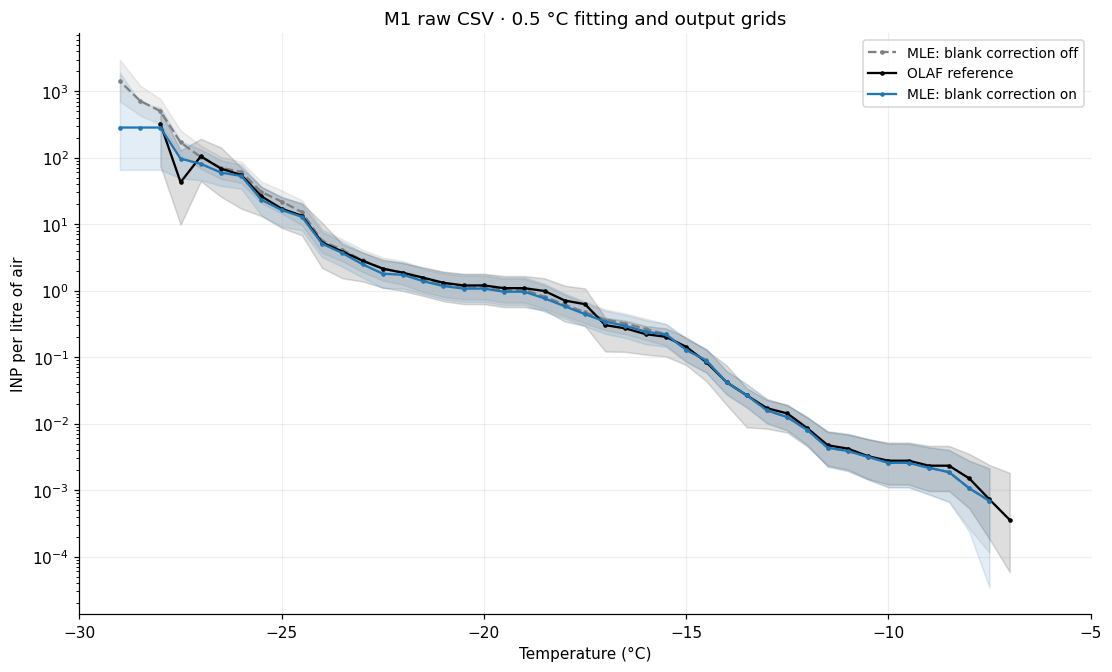

,temperature_C,without_blank_INP_L,with_blank_INP_L,OLAF_INP_L
0,-10.0,0.002569,0.002569,0.002769
1,-15.0,0.129276,0.128810,0.143033
2,-20.0,1.147960,1.073899,1.199122
3,-25.0,21.918152,16.322468,17.082683
4,-28.0,501.513497,284.553342,324.103108


Verified: original CSV and OLAF reference unchanged; raw counts preserved.


In [4]:
def draw(ax, data, *, label, color, linestyle="-", shade=True):
    positive = np.isfinite(data.concentration) & data.concentration.gt(0)
    ax.plot(data.temperature_C, data.concentration.where(positive), label=label,
            color=color, linestyle=linestyle, marker=".", ms=4, lw=1.5)
    if shade:
        lower = data.concentration - data.lower_error
        upper = data.concentration + data.upper_error
        visible = positive & lower.gt(0) & np.isfinite(upper)
        ax.fill_between(data.temperature_C, lower.where(visible), upper.where(visible),
                        color=color, alpha=.13)

fig, ax = plt.subplots(figsize=(10, 6), layout="constrained")
draw(ax, results[False], label="MLE: blank correction off", color="0.5", linestyle="--")
draw(ax, reference, label="OLAF reference", color="black")
draw(ax, results[True], label="MLE: blank correction on", color="C0")
ax.set(yscale="log", xlim=(-30, -5), xlabel="Temperature (°C)", ylabel="INP per litre of air",
       title="M1 raw CSV · 0.5 °C fitting and output grids")
ax.legend(fontsize=9)
ax.grid(alpha=.2)
plt.show()
comparison = pd.DataFrame({"temperature_C": [-10., -15., -20., -25., -28.]})
for corrected, label in [(False, "without_blank_INP_L"), (True, "with_blank_INP_L")]:
    comparison = comparison.merge(results[corrected][["temperature_C", "concentration"]].rename(
        columns={"concentration": label}), on="temperature_C", how="left", validate="one_to_one")
comparison = comparison.merge(reference[["temperature_C", "concentration"]].rename(
    columns={"concentration": "OLAF_INP_L"}), on="temperature_C", how="left", validate="one_to_one")
display(comparison)
assert hashlib.sha256(DATA_PATH.read_bytes()).hexdigest() == source_sha256
assert hashlib.sha256(REFERENCE_PATH.read_bytes()).hexdigest() == reference_sha256
print("Verified: original CSV and OLAF reference unchanged; raw counts preserved.")
